In [ ]:
!pip install fuzzywuzzy python-Levenshtein xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 36.2 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

print("Setup complete!")

Setup complete!


In [ ]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.corpus import stopwords
import re

# Feature engineering
from fuzzywuzzy import fuzz

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from xgboost import XGBClassifier

print("All libraries imported!")

All libraries imported!


In [ ]:
from google.colab import files

uploaded = files.upload()   # A button appears — click and select train.csv

df = pd.read_csv('train.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Saving train.csv to train.csv
Shape: (404290, 6)
Columns: ['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate']


,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


Missing values:
 id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

Duplicate distribution:
is_duplicate
0    255027
1    149263
Name: count, dtype: int64


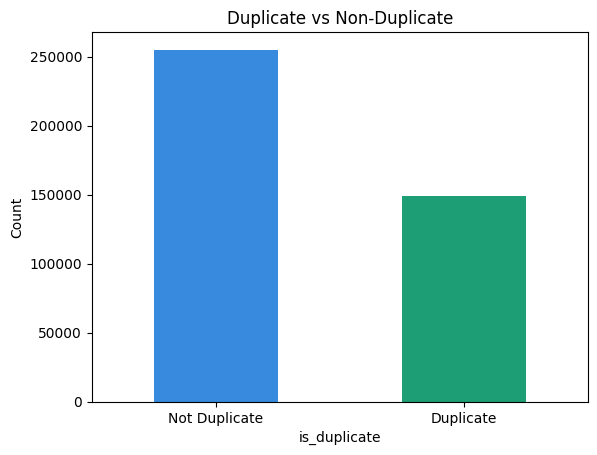

In [5]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Check class balance
print("\nDuplicate distribution:")
print(df['is_duplicate'].value_counts())

# Visualize class balance
df['is_duplicate'].value_counts().plot(kind='bar', color=['#378ADD', '#1D9E75'])
plt.title('Duplicate vs Non-Duplicate')
plt.xticks([0, 1], ['Not Duplicate', 'Duplicate'], rotation=0)
plt.ylabel('Count')
plt.show()

In [6]:
# Handle missing values first
df = df.fillna('')

# Feature 1: Length of each question
df['q1_len'] = df['question1'].apply(len)
df['q2_len'] = df['question2'].apply(len)

# Feature 2: Number of words
df['q1_num_words'] = df['question1'].apply(lambda x: len(x.split()))
df['q2_num_words'] = df['question2'].apply(lambda x: len(x.split()))

# Feature 3: Common words between questions
def common_words(row):
    w1 = set(row['question1'].lower().split())
    w2 = set(row['question2'].lower().split())
    return len(w1 & w2)

df['word_common'] = df.apply(common_words, axis=1)

# Feature 4: Word share ratio
df['word_total'] = df['q1_num_words'] + df['q2_num_words']
df['word_share'] = round(df['word_common'] / df['word_total'], 2)

# Feature 5: Fuzzy matching score
df['fuzz_ratio'] = df.apply(
    lambda x: fuzz.ratio(x['question1'], x['question2']), axis=1)

print("Features created!")
df[['q1_len','q2_len','word_common','word_share','fuzz_ratio']].head()


Features created!


,q1_len,q2_len,word_common,word_share,fuzz_ratio
0,66,57,10,0.38,93
1,51,88,4,0.19,65
2,73,59,4,0.17,55
3,50,65,0,0.00,28
4,76,39,2,0.10,45


In [8]:
def predict_duplicate(q1, q2):
    q1_len = len(q1)
    q2_len = len(q2)
    q1_words = len(q1.split())
    q2_words = len(q2.split())
    w1 = set(q1.lower().split())
    w2 = set(q2.lower().split())
    common = len(w1 & w2)
    total = q1_words + q2_words
    share = round(common / total, 2) if total > 0 else 0
    fuzzy = fuzz.ratio(q1, q2)

    features = [[q1_len, q2_len, q1_words, q2_words, common, share, fuzzy]]
    result = model.predict(features)[0]
    return "DUPLICATE" if result == 1 else "NOT DUPLICATE"

# Test it!
q1 = "How do I learn Python?"
q2 = "What is the best way to learn Python?"
print(predict_duplicate(q1, q2))

NOT DUPLICATE


In [9]:
# Add these 3 extra fuzzy features
df['fuzz_partial'] = df.apply(
    lambda x: fuzz.partial_ratio(x['question1'], x['question2']), axis=1)

df['fuzz_token_sort'] = df.apply(
    lambda x: fuzz.token_sort_ratio(x['question1'], x['question2']), axis=1)

df['fuzz_token_set'] = df.apply(
    lambda x: fuzz.token_set_ratio(x['question1'], x['question2']), axis=1)

# Update features list
features = ['q1_len', 'q2_len', 'q1_num_words', 'q2_num_words',
            'word_common', 'word_share', 'fuzz_ratio',
            'fuzz_partial', 'fuzz_token_sort', 'fuzz_token_set']

# Retrain
X = df[features]
y = df['is_duplicate']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = XGBClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("New Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("New F1 Score:", round(f1_score(y_test, y_pred), 3))

New Accuracy: 73.64 %
New F1 Score: 0.664
